# Aufgabe 4.1 - Klassisches ML & Data Science

Dieses Notebook beantwortet die Textanalyse-Fragen und trainiert ein klassisches SPAM/HAM-Klassifikationsmodell. Es läuft vollständig lokal ohne externe ML- oder LLM-Dienste.

In [52]:
from pathlib import Path
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from dotenv import load_dotenv
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 140)

DATA_PATH = Path("data/01_cleaned/sms_cleaned.csv")
RANDOM_STATE = 42

load_dotenv()

False

## Daten laden

In [53]:
df = pd.read_csv(DATA_PATH, encoding="utf-8")
display(df.head())
display(df["label"].value_counts().to_frame("count"))

print(f"Labels found: {sorted(df['label'].dropna().unique())}")
print(f"Targets found: {sorted(df['target'].dropna().unique())}")
print(f"Missing values: {int(df[['label', 'target', 'message']].isna().sum().sum())}")

,label,target,message
0,ham,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,0,Ok lar... Joking wif u oni...
2,spam,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply ...
3,ham,0,U dun say so early hor... U c already then say...
4,ham,0,"Nah I don't think he goes to usf, he lives around here though"


,count
label,
ham,4516
spam,642


Labels found: ['ham', 'spam']
Targets found: [np.int64(0), np.int64(1)]
Missing values: 0


## Warum diese Bibliotheken und Modelle?

- `pandas`/`numpy`: Standard für tabellarische Daten und robuste, nachvollziehbare Auswertungen.
- `scikit-learn`: etabliert für klassische Textklassifikation, Pipelines, Vektorisierung und Evaluation.
- `CountVectorizer`: einfache Bag-of-Words-/N-Gram-Zählung ohne TF-IDF-Gewichtung. Das ist eine wichtige Baseline, weil sie zeigt, wie weit reine Wortzählungen tragen.
- `TfidfVectorizer`: gewichtet Wörter zusätzlich nach Spezifität. Häufige, wenig informative Wörter werden abgeschwächt.
- `DummyClassifier`: notwendige Baseline, damit echte Modelle gegen triviale Strategien verglichen werden. Die Majority-Baseline sagt immer `ham`; deshalb sind SPAM-Precision, SPAM-Recall und SPAM-F1 dort absichtlich 0.
- `MultinomialNB`: sehr starke klassische Baseline für Wortzählungen und kurze Texte.
- `LogisticRegression`: lineares, interpretierbares Hauptmodell mit gut lesbaren Feature-Gewichten.
- `LinearSVC`: robuster Vergleich für sparse Textfeatures.

Verglichen werden sowohl Count-basierte Modelle ohne TF-IDF als auch TF-IDF-basierte Varianten. So sieht man, ob die zusätzliche TF-IDF-Gewichtung tatsächlich hilft oder ob reine Wort-/N-Gram-Zählungen bereits reichen.

Nicht als Hauptlösung gewählt für 4.1: Word2Vec/FastText/Deep Learning. Für die klassische Aufgabe ist der Interpretierbarkeits- und Reproduzierbarkeitsgewinn klassischer Modelle wichtig. Deep-Learning-Modelle werden weiter unten zusätzlich als Vergleich trainiert.

## Häufigste Wörter insgesamt und pro Klasse

In [54]:
token_pattern = r"(?u)\b[a-zA-Z][a-zA-Z']+\b"

def top_terms(texts, ngram_range=(1, 1), top_n=25, stop_words="english"):
    vectorizer = CountVectorizer(lowercase=True, token_pattern=token_pattern, ngram_range=ngram_range, stop_words=stop_words)
    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    result = pd.DataFrame({"term": terms, "count": counts}).sort_values("count", ascending=False)
    return result.head(top_n).reset_index(drop=True)

top_all = top_terms(df["message"], top_n=30)
top_ham = top_terms(df.loc[df["label"] == "ham", "message"], top_n=30)
top_spam = top_terms(df.loc[df["label"] == "spam", "message"], top_n=30)

display(top_all)
display(top_ham)
display(top_spam)

,term,count
0,i'm,378
1,just,348
2,ur,322
3,ok,261
4,free,246
5,know,244
6,like,236
7,got,233
8,good,229
9,come,216


,term,count
0,i'm,370
1,just,282
2,ok,256
3,got,227
4,know,226
5,like,224
6,good,217
7,come,214
8,ur,203
9,time,193


,term,count
0,free,190
1,txt,132
2,ur,119
3,stop,111
4,text,108
5,mobile,105
6,reply,96
7,claim,95
8,www,81
9,prize,79


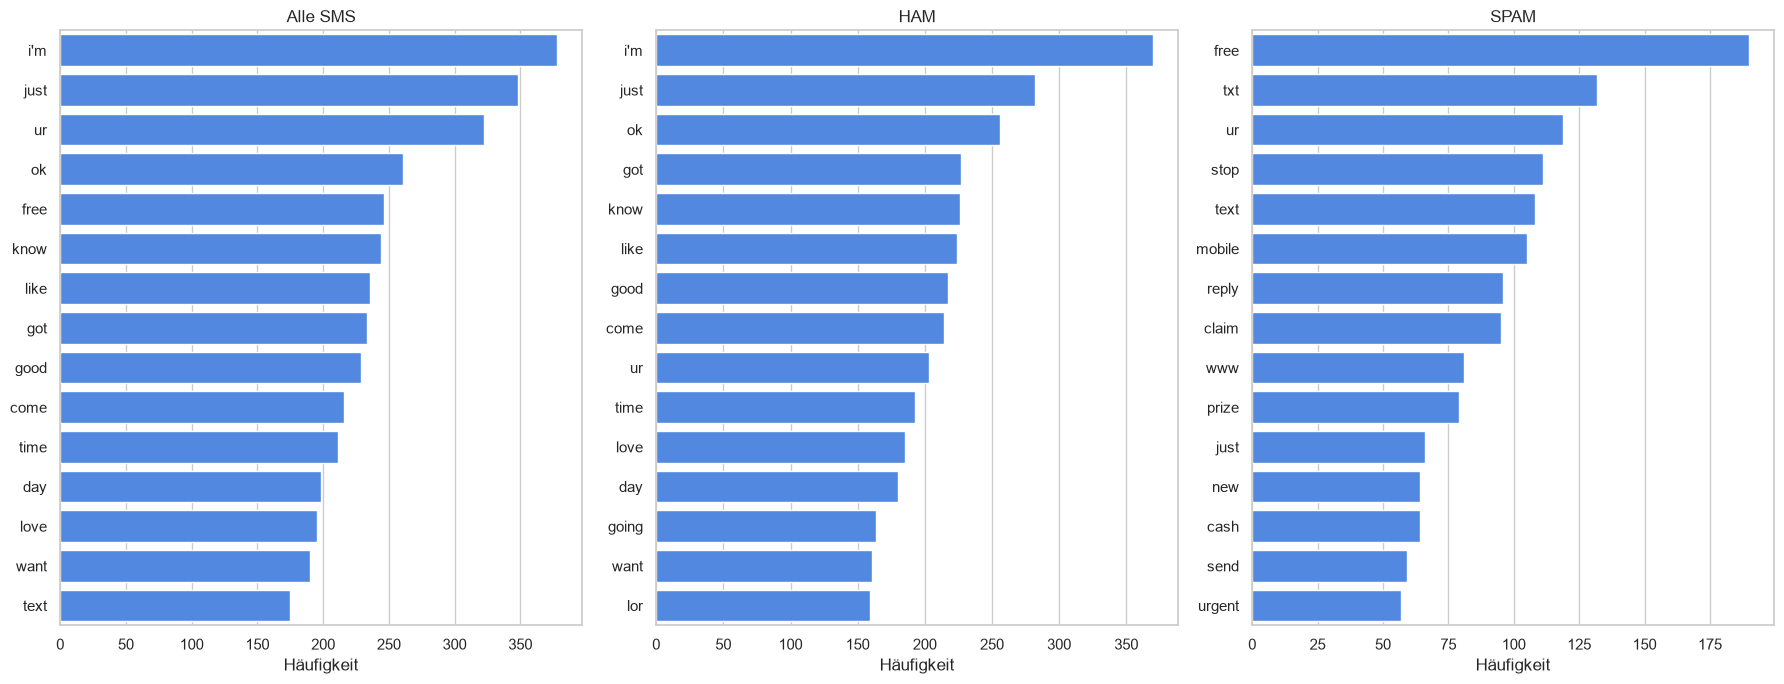

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, data, title in zip(axes, [top_all, top_ham, top_spam], ["Alle SMS", "HAM", "SPAM"]):
    sns.barplot(data=data.head(15), y="term", x="count", ax=ax, color="#3b82f6")
    ax.set_title(title)
    ax.set_xlabel("Häufigkeit")
    ax.set_ylabel("")
plt.tight_layout()

## Typische Wörter für HAM vs. SPAM

Für typische Wörter nutzen wir die Gewichte einer logistischen Regression auf TF-IDF-Features. Positive Koeffizienten sprechen für SPAM, negative für HAM.

In [56]:
interpretability_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(lowercase=True, token_pattern=token_pattern, ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)
interpretability_pipeline.fit(df["message"], df["target"])

feature_names = interpretability_pipeline.named_steps["tfidf"].get_feature_names_out()
coefs = interpretability_pipeline.named_steps["model"].coef_[0]

typical_spam = pd.DataFrame({"term": feature_names, "weight": coefs}).sort_values("weight", ascending=False).head(25)
typical_ham = pd.DataFrame({"term": feature_names, "weight": coefs}).sort_values("weight", ascending=True).head(25)

display(typical_spam.reset_index(drop=True))
display(typical_ham.reset_index(drop=True))

,term,weight
0,call,6.063618
1,txt,5.760192
2,free,4.669230
3,text,4.483831
4,to,3.747331
5,reply,3.580211
6,stop,3.483847
7,your,3.397885
8,www,3.326178
9,mobile,3.292596


,term,weight
0,my,-2.545553
1,me,-2.474482
2,ok,-1.985424
3,i'm,-1.816268
4,that,-1.740174
5,but,-1.611433
6,it,-1.610900
7,come,-1.551513
8,da,-1.500552
9,then,-1.467374


## Häufige Wortgruppen: Bigrams und Trigrams

In [57]:
display(top_terms(df["message"], ngram_range=(2, 2), top_n=25))
display(top_terms(df["message"], ngram_range=(3, 3), top_n=25))
display(top_terms(df.loc[df["label"] == "spam", "message"], ngram_range=(2, 3), top_n=25))
display(top_terms(df.loc[df["label"] == "ham", "message"], ngram_range=(2, 3), top_n=25))

,term,count
0,let know,40
1,good morning,24
2,i'm going,22
3,po box,22
4,just got,22
5,new year,21
6,send stop,20
7,ok lor,19
8,hi hi,19
9,prize guaranteed,19


,term,count
0,happy new year,16
1,private account statement,15
2,identifier code expires,14
3,prize guaranteed land,13
4,draw shows won,13
5,guaranteed land line,13
6,shows won prize,12
7,shows redeemed points,12
8,land line claim,12
9,account statement shows,12


,term,count
0,po box,21
1,prize guaranteed,19
2,send stop,19
3,national rate,17
4,urgent mobile,17
5,selected receive,16
6,land line,16
7,txt stop,16
8,identifier code,15
9,private account,15


,term,count
0,let know,40
1,good morning,24
2,i'm going,22
3,new year,21
4,just got,20
5,ok lor,19
6,wat time,18
7,hi hi,18
8,happy new,17
9,good night,17


## SPAM/HAM-Klassifikationsmodell

Textrepräsentation:
- Naive Bayes nutzt Count-Vektoren, weil MultinomialNB auf Häufigkeiten modelliert ist.
- Logistische Regression und LinearSVC nutzen TF-IDF, weil dadurch sehr häufige Wörter weniger dominieren.

Evaluation:
- Stratified Train/Validation/Test Split bewahrt die Klassenverteilung.
- Validation entscheidet Modellwahl, Hyperparameter und bei Deep Learning die Anzahl Epochen.
- Test wird erst am Ende für die finale Bewertung genutzt.
- Neben Accuracy werden Precision, Recall und F1 für SPAM betrachtet, weil SPAM die Minderheitsklasse ist.

In [58]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df["message"],
    df["target"],
    test_size=0.2,
    stratify=df["target"],
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

print(f"Train rows: {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Test rows: {len(X_test)}")

models = {
    "Dummy majority baseline": Pipeline([("model", DummyClassifier(strategy="most_frequent"))]),
    "Dummy stratified baseline": Pipeline([("model", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))]),
    "MultinomialNB + Count": Pipeline([
        ("count", CountVectorizer(lowercase=True, token_pattern=token_pattern, ngram_range=(1, 2), min_df=2)),
        ("model", MultinomialNB()),
    ]),
    "LogisticRegression + Count": Pipeline([
        ("count", CountVectorizer(lowercase=True, token_pattern=token_pattern, ngram_range=(1, 2), min_df=2)),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "LinearSVC + Count": Pipeline([
        ("count", CountVectorizer(lowercase=True, token_pattern=token_pattern, ngram_range=(1, 2), min_df=2)),
        ("model", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "LogisticRegression + TF-IDF": Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True, token_pattern=token_pattern, ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "LinearSVC + TF-IDF": Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True, token_pattern=token_pattern, ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("model", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}

def binary_metric_row(model_name, split_name, y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        pos_label=1,
        zero_division=0,
    )
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": (np.asarray(y_pred) == np.asarray(y_true)).mean(),
        "spam_precision": precision,
        "spam_recall": recall,
        "spam_f1": f1,
    }

validation_rows = []
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_val_pred = pipeline.predict(X_val)
    validation_rows.append(binary_metric_row(name, "validation", y_val, y_val_pred))

validation_results_df = pd.DataFrame(validation_rows).sort_values("spam_f1", ascending=False)
display(validation_results_df.round(4))

best_model_name = validation_results_df.iloc[0]["model"]
print(f"Bestes klassisches Modell nach Validation-SPAM-F1: {best_model_name}")

all_test_results = []
classic_test_predictions = {}
for name, pipeline in models.items():
    pipeline.fit(X_train_full, y_train_full)
    y_test_pred = pipeline.predict(X_test)
    classic_test_predictions[name] = y_test_pred
    all_test_results.append(binary_metric_row(name, "test", y_test, y_test_pred))

best_predictions = classic_test_predictions[best_model_name]
classic_test_results_df = pd.DataFrame(all_test_results).sort_values("spam_f1", ascending=False)
display(classic_test_results_df.round(4))

Train rows: 3300
Validation rows: 826
Test rows: 1032


c:\dev\repos\a1\a1-bewerbung\.venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,model,split,accuracy,spam_precision,spam_recall,spam_f1
6,LinearSVC + TF-IDF,validation,0.9818,0.9490,0.9029,0.9254
4,LinearSVC + Count,validation,0.9806,0.9677,0.8738,0.9184
3,LogisticRegression + Count,validation,0.9782,0.9293,0.8932,0.9109
5,LogisticRegression + TF-IDF,validation,0.9770,0.9038,0.9126,0.9082
2,MultinomialNB + Count,validation,0.9758,0.9368,0.8641,0.8990
1,Dummy stratified baseline,validation,0.7712,0.1228,0.1359,0.1290
0,Dummy majority baseline,validation,0.8753,0.0000,0.0000,0.0000


Bestes klassisches Modell nach Validation-SPAM-F1: LinearSVC + TF-IDF


c:\dev\repos\a1\a1-bewerbung\.venv\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,model,split,accuracy,spam_precision,spam_recall,spam_f1
4,LinearSVC + Count,test,0.9845,0.9828,0.8906,0.9344
6,LinearSVC + TF-IDF,test,0.9826,0.9365,0.9219,0.9291
3,LogisticRegression + Count,test,0.9826,0.9508,0.9062,0.9280
5,LogisticRegression + TF-IDF,test,0.9777,0.8947,0.9297,0.9119
2,MultinomialNB + Count,test,0.9777,0.9268,0.8906,0.9084
1,Dummy stratified baseline,test,0.7645,0.0803,0.0859,0.0830
0,Dummy majority baseline,test,0.8760,0.0000,0.0000,0.0000


Finale Test-Evaluation für: LinearSVC + TF-IDF
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       904
        spam       0.94      0.92      0.93       128

    accuracy                           0.98      1032
   macro avg       0.96      0.96      0.96      1032
weighted avg       0.98      0.98      0.98      1032



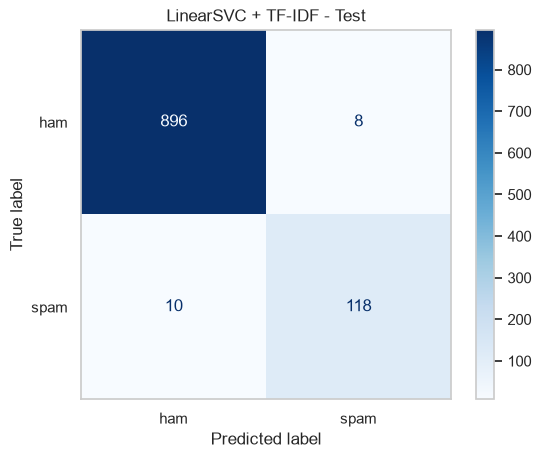

In [59]:
print(f"Finale Test-Evaluation für: {best_model_name}")
print(classification_report(y_test, best_predictions, target_names=["ham", "spam"], zero_division=0))

cm = confusion_matrix(y_test, best_predictions)
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(cmap="Blues", values_format="d")
plt.title(f"{best_model_name} - Test")
plt.grid(False)

## Optional: Deep Learning Vergleich mit LSTM und Transformer

Die folgenden Zellen gehen über klassisches ML hinaus. Sie sind sinnvoll als Zusatzvergleich, weil SMS kurze Sequenzen sind und moderne Transformer/BERT-Modelle semantische Muster anders abbilden als TF-IDF. Für die eigentliche klassische Aufgabe bleiben die scikit-learn-Modelle oben die schnellere und besser interpretierbare Hauptlösung.

Für LSTM und DistilBERT wird derselbe Train/Validation/Test Split verwendet. Train lernt, Validation steuert Early Stopping, und Test wird erst am Ende bewertet.

Warum kein xLSTM als Standard: xLSTM ist interessant, aber nicht Teil der stabilen Standard-Toolchain von PyTorch oder Hugging Face Transformers. Für eine nachvollziehbare Abgabe ist ein normales LSTM als sequenzieller Neural-Baseline robuster. Falls eine stabile xLSTM-Bibliothek im Environment installiert ist, könnte sie später an derselben Stelle wie das LSTM ersetzt werden.

In [60]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, Dataset
    TORCH_AVAILABLE = True
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch available. Device: {DEVICE}")
except ImportError:
    TORCH_AVAILABLE = False
    DEVICE = None
    print("PyTorch not installed. Install requirements.txt to run LSTM/Transformer experiments.")

PyTorch available. Device: cuda


In [61]:
if TORCH_AVAILABLE:
    torch.manual_seed(RANDOM_STATE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)

    def simple_tokenize(text):
        return re.findall(r"[a-zA-Z0-9']+", text.lower())

    train_tokens = [simple_tokenize(text) for text in X_train]
    min_freq = 2
    token_counts = pd.Series([token for tokens in train_tokens for token in tokens]).value_counts()
    vocab = {"<pad>": 0, "<unk>": 1}
    for token in token_counts[token_counts >= min_freq].index:
        vocab[token] = len(vocab)

    MAX_LEN = 64

    def encode_tokens(text):
        ids = [vocab.get(token, vocab["<unk>"]) for token in simple_tokenize(text)[:MAX_LEN]]
        ids = ids + [vocab["<pad>"]] * (MAX_LEN - len(ids))
        return ids

    class SmsSequenceDataset(Dataset):
        def __init__(self, texts, labels):
            self.encoded = torch.tensor([encode_tokens(text) for text in texts], dtype=torch.long)
            self.labels = torch.tensor(labels.to_numpy(), dtype=torch.float32)

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, idx):
            return self.encoded[idx], self.labels[idx]

    train_loader = DataLoader(SmsSequenceDataset(X_train, y_train), batch_size=64, shuffle=True)
    val_loader = DataLoader(SmsSequenceDataset(X_val, y_val), batch_size=256, shuffle=False)
    test_loader = DataLoader(SmsSequenceDataset(X_test, y_test), batch_size=256, shuffle=False)

    class SmsLSTMClassifier(nn.Module):
        def __init__(self, vocab_size, embedding_dim=96, hidden_dim=96, dropout=0.3):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
            self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
            self.dropout = nn.Dropout(dropout)
            self.output = nn.Linear(hidden_dim * 2, 1)

        def forward(self, input_ids):
            embedded = self.embedding(input_ids)
            _, (hidden, _) = self.lstm(embedded)
            features = torch.cat([hidden[-2], hidden[-1]], dim=1)
            return self.output(self.dropout(features)).squeeze(1)

    def predict_lstm(model, loader):
        model.eval()
        probs = []
        labels = []
        with torch.no_grad():
            for batch_ids, batch_labels in loader:
                logits = model(batch_ids.to(DEVICE))
                probs.extend(torch.sigmoid(logits).cpu().numpy())
                labels.extend(batch_labels.cpu().numpy())
        pred = (np.asarray(probs) >= 0.5).astype(int)
        return np.asarray(labels).astype(int), pred

    lstm_model = SmsLSTMClassifier(vocab_size=len(vocab)).to(DEVICE)
    positive_weight = torch.tensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)], dtype=torch.float32, device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
    optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=2e-3, weight_decay=1e-4)

    MAX_EPOCHS = 15
    PATIENCE = 3
    best_val_f1 = -1.0
    best_state = None
    epochs_without_improvement = 0
    lstm_history = []

    for epoch in range(MAX_EPOCHS):
        lstm_model.train()
        epoch_loss = 0.0
        for batch_ids, batch_labels in train_loader:
            batch_ids = batch_ids.to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(lstm_model(batch_ids), batch_labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_labels)

        y_val_true, y_val_pred = predict_lstm(lstm_model, val_loader)
        val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
            y_val_true,
            y_val_pred,
            average="binary",
            pos_label=1,
            zero_division=0,
        )
        avg_loss = epoch_loss / len(y_train)
        lstm_history.append({"epoch": epoch + 1, "train_loss": avg_loss, "val_spam_precision": val_precision, "val_spam_recall": val_recall, "val_spam_f1": val_f1})
        print(f"Epoch {epoch + 1}/{MAX_EPOCHS} - loss: {avg_loss:.4f} - val_spam_f1: {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {key: value.detach().cpu().clone() for key, value in lstm_model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f"Early stopping after {epoch + 1} epochs. Best validation SPAM-F1: {best_val_f1:.4f}")
                break

    display(pd.DataFrame(lstm_history).round(4))

    if best_state is not None:
        lstm_model.load_state_dict({key: value.to(DEVICE) for key, value in best_state.items()})

    y_test_true_lstm, lstm_pred = predict_lstm(lstm_model, test_loader)
    lstm_test_row = binary_metric_row("BiLSTM + learned embeddings", "test", y_test_true_lstm, lstm_pred)
    all_test_results.append(lstm_test_row)
    print("Finale LSTM-Test-Evaluation:")
    print(classification_report(y_test_true_lstm, lstm_pred, target_names=["ham", "spam"], zero_division=0))
    display(pd.DataFrame([lstm_test_row]).round(4))
else:
    print("Skipping LSTM experiment because PyTorch is unavailable.")

Epoch 1/15 - loss: 0.8318 - val_spam_f1: 0.5981
Epoch 2/15 - loss: 0.3313 - val_spam_f1: 0.8372
Epoch 3/15 - loss: 0.1856 - val_spam_f1: 0.8326
Epoch 4/15 - loss: 0.1100 - val_spam_f1: 0.8627
Epoch 5/15 - loss: 0.1019 - val_spam_f1: 0.8558
Epoch 6/15 - loss: 0.0403 - val_spam_f1: 0.8976
Epoch 7/15 - loss: 0.0192 - val_spam_f1: 0.8942
Epoch 8/15 - loss: 0.0104 - val_spam_f1: 0.9000
Epoch 9/15 - loss: 0.0184 - val_spam_f1: 0.8304
Epoch 10/15 - loss: 0.0576 - val_spam_f1: 0.8614
Epoch 11/15 - loss: 0.0295 - val_spam_f1: 0.8824
Early stopping after 11 epochs. Best validation SPAM-F1: 0.9000


,epoch,train_loss,val_spam_precision,val_spam_recall,val_spam_f1
0,1,0.8318,0.4471,0.9029,0.5981
1,2,0.3313,0.8036,0.8738,0.8372
2,3,0.1856,0.7462,0.9417,0.8326
3,4,0.1100,0.8713,0.8544,0.8627
4,5,0.1019,0.8214,0.8932,0.8558
5,6,0.0403,0.9020,0.8932,0.8976
6,7,0.0192,0.8857,0.9029,0.8942
7,8,0.0104,0.9278,0.8738,0.9000
8,9,0.0184,0.7686,0.9029,0.8304
9,10,0.0576,0.8788,0.8447,0.8614


Finale LSTM-Test-Evaluation:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       904
        spam       0.93      0.91      0.92       128

    accuracy                           0.98      1032
   macro avg       0.96      0.95      0.96      1032
weighted avg       0.98      0.98      0.98      1032



,model,split,accuracy,spam_precision,spam_recall,spam_f1
0,BiLSTM + learned embeddings,test,0.9806,0.9286,0.9141,0.9213


## Optional: DistilBERT/BERT-Transformer

Dieses Experiment nutzt ein kleines BERT-aehnliches Modell (`distilbert-base-uncased`) und fine-tuned es direkt auf HAM/SPAM. Das ist rechenintensiver und weniger transparent als TF-IDF + Logistic Regression, kann aber semantische und kontextuelle Muster besser erfassen. Mit CUDA auf der 2080 Super sollte ein kurzer Run praktikabel sein.

In [62]:
RUN_TRANSFORMER = True  # Auf False setzen, wenn das Fine-Tuning übersprungen werden soll.

if RUN_TRANSFORMER:
    try:
        from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
        from transformers.utils import logging as hf_logging
        from huggingface_hub.utils import logging as hf_hub_logging
    except ImportError as exc:
        raise ImportError("Install transformers and torch from requirements.txt to run this section.") from exc

    if not TORCH_AVAILABLE:
        raise ImportError("PyTorch is required for transformer fine-tuning.")

    hf_logging.set_verbosity_error()
    hf_hub_logging.set_verbosity_error()
    hf_token = os.getenv("HF_TOKEN") or None
    TRANSFORMER_MODEL = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL, token=hf_token)
    print("Hinweis: Die Classification-Head-Gewichte von DistilBERT werden für HAM/SPAM neu initialisiert. Das ist beim Fine-Tuning erwartet.")

    class SmsTransformerDataset(Dataset):
        def __init__(self, texts, labels):
            self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=96)
            self.labels = list(labels)

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, idx):
            item = {key: torch.tensor(value[idx]) for key, value in self.encodings.items()}
            item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
            return item

    transformer_train_loader = DataLoader(SmsTransformerDataset(X_train, y_train), batch_size=16, shuffle=True)
    transformer_val_loader = DataLoader(SmsTransformerDataset(X_val, y_val), batch_size=32, shuffle=False)
    transformer_test_loader = DataLoader(SmsTransformerDataset(X_test, y_test), batch_size=32, shuffle=False)

    transformer_model = AutoModelForSequenceClassification.from_pretrained(
        TRANSFORMER_MODEL,
        num_labels=2,
        token=hf_token,
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=2e-5)

    MAX_EPOCHS = 5
    PATIENCE = 2
    total_steps = len(transformer_train_loader) * MAX_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

    def predict_transformer(model, loader):
        model.eval()
        predictions = []
        labels_all = []
        with torch.no_grad():
            for batch in loader:
                labels = batch.pop("labels")
                labels_all.extend(labels.cpu().numpy())
                batch = {key: value.to(DEVICE) for key, value in batch.items()}
                logits = model(**batch).logits
                predictions.extend(torch.argmax(logits, dim=1).cpu().numpy())
        return np.asarray(labels_all), np.asarray(predictions)

    best_val_f1 = -1.0
    best_state = None
    epochs_without_improvement = 0
    transformer_history = []

    for epoch in range(MAX_EPOCHS):
        transformer_model.train()
        total_loss = 0.0
        for batch in transformer_train_loader:
            batch = {key: value.to(DEVICE) for key, value in batch.items()}
            optimizer.zero_grad()
            outputs = transformer_model(**batch)
            outputs.loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += outputs.loss.item() * batch["labels"].size(0)

        y_val_true_transformer, y_val_pred_transformer = predict_transformer(transformer_model, transformer_val_loader)
        val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
            y_val_true_transformer,
            y_val_pred_transformer,
            average="binary",
            pos_label=1,
            zero_division=0,
        )
        avg_loss = total_loss / len(y_train)
        transformer_history.append({"epoch": epoch + 1, "train_loss": avg_loss, "val_spam_precision": val_precision, "val_spam_recall": val_recall, "val_spam_f1": val_f1})
        print(f"Transformer epoch {epoch + 1}/{MAX_EPOCHS} - loss: {avg_loss:.4f} - val_spam_f1: {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {key: value.detach().cpu().clone() for key, value in transformer_model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f"Early stopping after {epoch + 1} epochs. Best validation SPAM-F1: {best_val_f1:.4f}")
                break

    display(pd.DataFrame(transformer_history).round(4))

    if best_state is not None:
        transformer_model.load_state_dict({key: value.to(DEVICE) for key, value in best_state.items()})

    y_test_true_transformer, transformer_pred = predict_transformer(transformer_model, transformer_test_loader)
    transformer_test_row = binary_metric_row("DistilBERT fine-tuned", "test", y_test_true_transformer, transformer_pred)
    all_test_results.append(transformer_test_row)
    print("Finale DistilBERT-Test-Evaluation:")
    print(classification_report(y_test_true_transformer, transformer_pred, target_names=["ham", "spam"], zero_division=0))
    display(pd.DataFrame([transformer_test_row]).round(4))
else:
    print("Transformer fine-tuning skipped. Set RUN_TRANSFORMER = True to run DistilBERT.")

Hinweis: Die Classification-Head-Gewichte von DistilBERT werden für HAM/SPAM neu initialisiert. Das ist beim Fine-Tuning erwartet.


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13070.03it/s]


Transformer epoch 1/5 - loss: 0.0981 - val_spam_f1: 0.9495
Transformer epoch 2/5 - loss: 0.0290 - val_spam_f1: 0.9505
Transformer epoch 3/5 - loss: 0.0116 - val_spam_f1: 0.9552
Transformer epoch 4/5 - loss: 0.0055 - val_spam_f1: 0.9552
Transformer epoch 5/5 - loss: 0.0029 - val_spam_f1: 0.9552
Early stopping after 5 epochs. Best validation SPAM-F1: 0.9552


,epoch,train_loss,val_spam_precision,val_spam_recall,val_spam_f1
0,1,0.0981,0.9895,0.9126,0.9495
1,2,0.0290,0.9697,0.9320,0.9505
2,3,0.0116,0.9796,0.9320,0.9552
3,4,0.0055,0.9796,0.9320,0.9552
4,5,0.0029,0.9796,0.9320,0.9552


Finale DistilBERT-Test-Evaluation:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       904
        spam       0.98      0.97      0.97       128

    accuracy                           0.99      1032
   macro avg       0.99      0.98      0.98      1032
weighted avg       0.99      0.99      0.99      1032



,model,split,accuracy,spam_precision,spam_recall,spam_f1
0,DistilBERT fine-tuned,test,0.9932,0.9764,0.9688,0.9725


## Finaler Modellvergleich auf dem Testdatensatz
Diese Tabelle vergleicht alle ausgeführten Modelle auf demselben Test-Split. Die klassischen Modelle sind immer enthalten; LSTM und DistilBERT erscheinen zusätzlich, sobald die jeweiligen Zellen ausgeführt wurden.

In [63]:
final_test_comparison = pd.DataFrame(all_test_results).drop_duplicates(subset=["model", "split"], keep="last")
final_test_comparison = final_test_comparison.sort_values("spam_f1", ascending=False).reset_index(drop=True)
display(final_test_comparison.round(4))

best_overall = final_test_comparison.iloc[0]
print(f"Bestes Modell auf dem Testdatensatz nach SPAM-F1: {best_overall['model']} ({best_overall['spam_f1']:.4f})")

,model,split,accuracy,spam_precision,spam_recall,spam_f1
0,DistilBERT fine-tuned,test,0.9932,0.9764,0.9688,0.9725
1,LinearSVC + Count,test,0.9845,0.9828,0.8906,0.9344
2,LinearSVC + TF-IDF,test,0.9826,0.9365,0.9219,0.9291
3,LogisticRegression + Count,test,0.9826,0.9508,0.9062,0.9280
4,BiLSTM + learned embeddings,test,0.9806,0.9286,0.9141,0.9213
5,LogisticRegression + TF-IDF,test,0.9777,0.8947,0.9297,0.9119
6,MultinomialNB + Count,test,0.9777,0.9268,0.8906,0.9084
7,Dummy stratified baseline,test,0.7645,0.0803,0.0859,0.0830
8,Dummy majority baseline,test,0.8760,0.0000,0.0000,0.0000


Bestes Modell auf dem Testdatensatz nach SPAM-F1: DistilBERT fine-tuned (0.9725)


## Ergebnisinterpretation

Das finale Modell sollte nicht nur nach Accuracy gewählt werden, weil ein Mehrheitsklassen-Modell bereits ca. 86,6% Accuracy erreicht. Entscheidend ist, ob SPAM mit hohem Recall gefunden wird, ohne zu viele HAM-Nachrichten falsch als SPAM zu markieren. Die logistische Regression ist als bevorzugtes Modell besonders gut erklärbar; falls `LinearSVC` im Test einen klar besseren SPAM-F1 erzielt, ist es eine plausible Alternative, aber etwas weniger direkt probabilistisch interpretierbar.